In [22]:
import all_samplers
import matplotlib.pyplot as plt
import numpy as np
import importlib as imp
import arviz as az

In [23]:
imp.reload(all_samplers)

<module 'all_samplers' from '/Users/triptesh_b/Downloads/Coursework/Research Skills/Group Project/rscam-mcmc-nonsmooth-sampling/all_samplers.py'>

In [24]:
config = all_samplers.SamplerConfig()

Sampling...
Done Gibbs sampling
Done MYULA sampling
Done Hadamard sampling


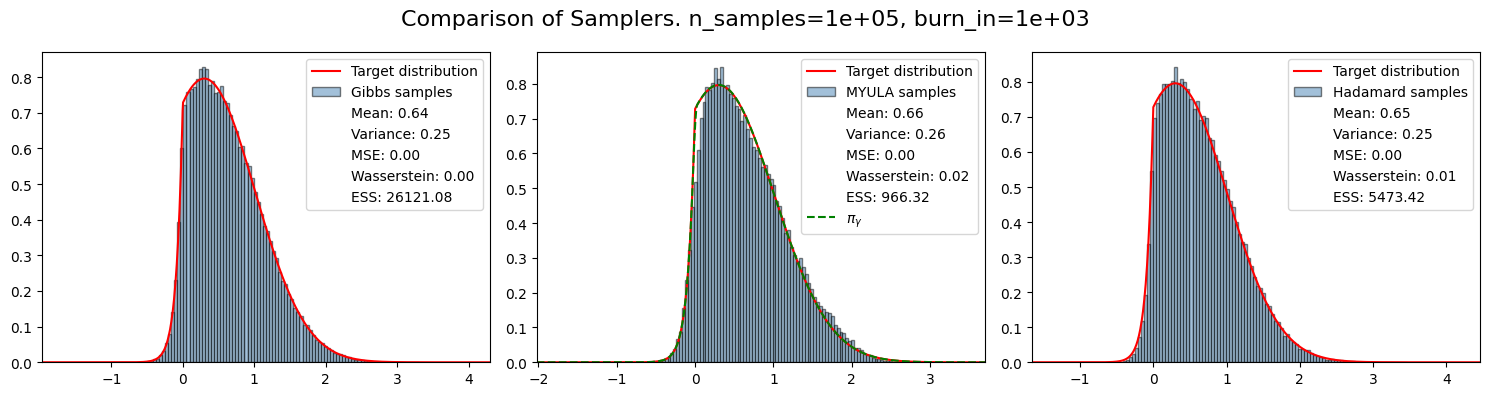

In [25]:
all_samplers.main_all()

In [26]:
gammas = np.logspace(-3, -1, 5)  # Example gamma values to test
mses = []
seconds = []
wass = []
samples = []
esss = []
for gamma in gammas:
    sample = all_samplers.myula_sampler(gamma, config)
    mses.append(config.mse_first_moment(sample))
    seconds.append(config.mse_second_moment(sample))
    wass.append(config.wassterstein(sample))
    samples.append(sample)
    esss.append(az.ess(sample))

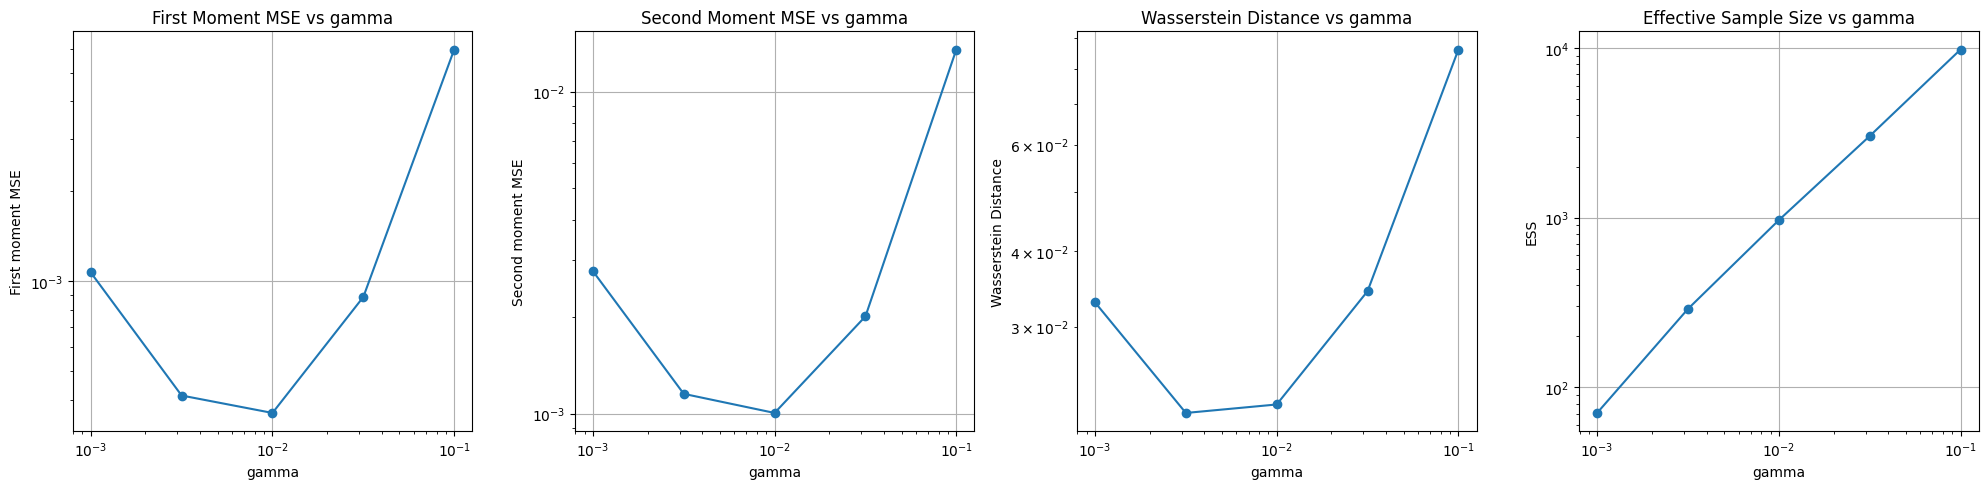

In [27]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].loglog(gammas, mses, marker='o')
axs[0].set_title('First Moment MSE vs gamma')
axs[0].set_ylabel('First moment MSE')
axs[1].loglog(gammas, seconds, marker='o')
axs[1].set_title('Second Moment MSE vs gamma')
axs[1].set_ylabel('Second moment MSE')
axs[2].loglog(gammas, wass, marker='o')
axs[2].set_title('Wasserstein Distance vs gamma')
axs[2].set_ylabel('Wasserstein Distance')
axs[3].loglog(gammas, esss, marker='o')
axs[3].set_title('Effective Sample Size vs gamma')
axs[3].set_ylabel('ESS')

for ax in axs:
    ax.set_xlabel('gamma')
    # ax.set_xticklabels(np.round(gammas))
    ax.grid()
plt.tight_layout()
plt.show()